# Study 293 -- MVRV-Ratio
## For the curious: does on-chain MVRV time Bitcoin tops and bottoms?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

"Sell when MVRV is over 3.5, buy when it's under 1." It is one of crypto's most
beloved on-chain rules. **MVRV** -- market value divided by *realized* value
(every coin priced at the moment it last moved on-chain) -- is sold as a
contrarian valuation gauge: high MVRV means euphoria and an over-valued top, low
MVRV means capitulation and a bottom.

We test it honestly. The trouble is that realized value is a slow average of
*past* prices, so MVRV and price are mechanically linked -- and Bitcoin has only
had about four cycles, so the "sell" band is calibrated to a handful of tops. The
real questions: does MVRV predict *next* month's return, and does a contrarian
rule beat simply **holding** BTC?


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mvrv_ratio import data, strategy as st

CACHE_PATH = data.BTC_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    df = data.joined_real(fetch=False, cache_path=CACHE_PATH)
    reg = st.predictive_regression(df)
    pos = st.timing_signal(df, high=3.5, low=1.0)
    bt = st.backtest_timing(df, pos, cost_bps=30.0)
    print(f"Real tape: {len(df)} aligned months  {df.index[0].date()} -> {df.index[-1].date()}")
else:
    df = reg = pos = bt = None
    print("No real BTC cache -- frozen headline numbers from R dict will be used")


Real tape: 141 aligned months  2014-09-30 -> 2026-05-31


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 140, 'n_mvrv': 149, 'reg_slope': -0.0067, 'reg_t': -0.15, 'reg_r2': 0.0, 'horse_mvrv_t': -0.7, 'horse_price_t': 1.88, 'band_over_mo': -6.7, 'band_over_n': 4, 'band_over_hit': 0.25, 'band_neutral_mo': 6.39, 'band_neutral_n': 111, 'band_under_mo': 4.97, 'band_under_n': 25, 'tim_share': 0.972, 'tim_turnover': 0.029, 'timing_ann': 71.4, 'timing_t': 2.89, 'timing_sr': 1.03, 'bh_ann': 69.2, 'bh_t': 2.74, 'bh_sr': 0.97, 'excess_ann': 2.2, 'excess_t': 0.59, 'high30_ann': 60.1, 'high40_ann': 71.5, 'syn_slope': -0.474, 'syn_t': -9.6, 'syn_null_t': 0.52}


## The MVRV oscillator everyone points at

Plot MVRV and you get a tidy oscillator: it spikes above ~3.5 at the 2017 and
2021 tops and sinks below ~1.0 at the 2018 and 2022 bottoms. It *looks* like a
perfect market timer in hindsight -- which is exactly the problem with a band
drawn after the fact through four extremes.


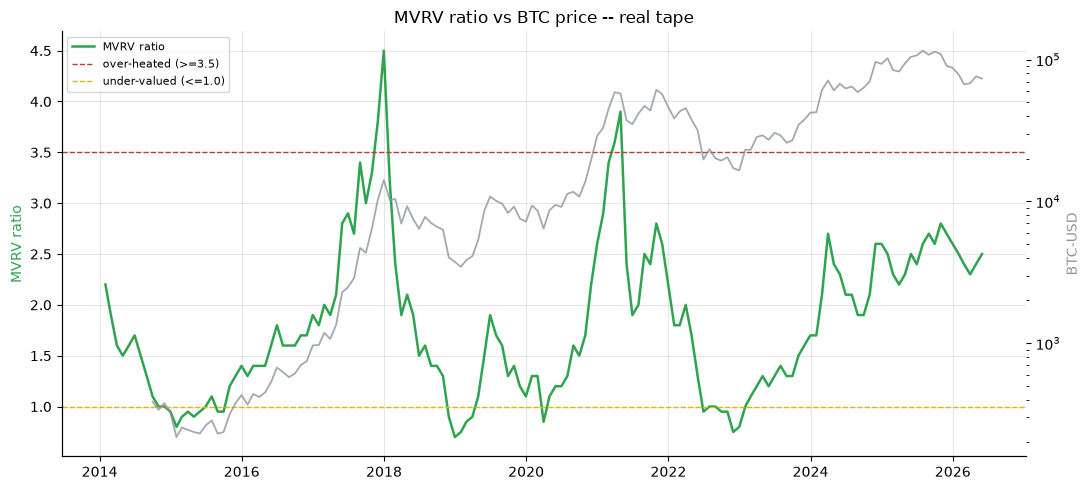

MVRV spikes at tops and sinks at bottoms IN HINDSIGHT. The question is
whether today's MVRV predicts NEXT month's return -- out of sample.


In [3]:
mv = data.mvrv_series()
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(mv.index, mv.values, color=GREEN, lw=1.8, label="MVRV ratio")
ax1.axhline(3.5, color=RED, ls="--", lw=1.0, label="over-heated (>=3.5)")
ax1.axhline(1.0, color=AMBER, ls="--", lw=1.0, label="under-valued (<=1.0)")
ax1.set_ylabel("MVRV ratio", color=GREEN)
ax2 = ax1.twinx()
if HAVE_REAL:
    ax2.plot(df.index, df["price"].values, color=GREY, lw=1.3, alpha=0.8, label="BTC-USD")
    ttl = "MVRV ratio vs BTC price -- real tape"
else:
    ax2.text(0.5, 0.5, "BTC cache absent -- MVRV shown alone",
             ha="center", va="center", transform=ax2.transAxes, fontsize=11, color=GREY)
    ttl = "MVRV ratio (BTC cache absent)"
ax2.set_ylabel("BTC-USD", color=GREY)
ax2.set_yscale("log")
ax2.grid(False)
ax1.set_title(ttl)
ax1.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("../docs/mvrv_vs_price.png", dpi=120, bbox_inches="tight")
plt.show()
print("MVRV spikes at tops and sinks at bottoms IN HINDSIGHT. The question is")
print("whether today's MVRV predicts NEXT month's return -- out of sample.")


## The honest test: does this month's MVRV predict next month's return?

Forget the picture. The tradable claim is contrarian: if MVRV is *stretched*
high this month, BTC should fall *next* month. We regress next-month BTC return
on this month's MVRV stretch (log of MVRV vs its mid-band).


In [4]:
if HAVE_REAL:
    print("Predictive regression  r(t+1) = a + b * MVRV_stretch(t)")
    print(f"  slope b = {reg['slope_mvrv']:+.4f}   HAC t = {reg['t_mvrv']:+.2f}   R^2 = {reg['r2']:.3f}   n = {reg['n']}")
else:
    print(f"Frozen: slope b = {R['reg_slope']:+.4f}  HAC t = {R['reg_t']:+.2f}  R^2 = {R['reg_r2']:.3f}  n = {R['n_months']}")
print()
print("The slope has the right (negative, contrarian) sign -- but it is")
print("statistically indistinguishable from zero (|t| < 2, R^2 ~ 0).")
print("MVRV stretch does NOT lead next-month BTC returns.")


Predictive regression  r(t+1) = a + b * MVRV_stretch(t)
  slope b = -0.0067   HAC t = -0.15   R^2 = 0.000   n = 140

The slope has the right (negative, contrarian) sign -- but it is
statistically indistinguishable from zero (|t| < 2, R^2 ~ 0).
MVRV stretch does NOT lead next-month BTC returns.


## "But the over-heated band nailed the tops!" -- on four months

The one place MVRV looks predictive is the over-heated band: months with
MVRV >= 3.5 are followed by an average **-6.7%** the next month. Impressive --
until you count how many months actually triggered it.


In [5]:
if HAVE_REAL:
    tab = st.state_forward_stats(df, high=3.5, low=1.0)
    print(tab.to_string())
    over_mo = tab.loc["over-heated", "mean"]*100; over_n = int(tab.loc["over-heated", "n"])
else:
    print("over-heated  : %+.2f%%/mo  n=%d" % (R['band_over_mo'], R['band_over_n']))
    print("neutral      : %+.2f%%/mo  n=%d" % (R['band_neutral_mo'], R['band_neutral_n']))
    print("under-valued : %+.2f%%/mo  n=%d" % (R['band_under_mo'], R['band_under_n']))
    over_mo, over_n = R['band_over_mo'], R['band_over_n']
print()
print(f"The over-heated band fires only {over_n} times in the whole sample.")
print("That is the 2017 and 2021 tops and nothing else -- anecdote, not evidence.")
print("And the under-valued 'buy' band does NOT beat ordinary neutral months.")


                  mean    n       hit
band                                 
over-heated  -0.067011    4  0.250000
neutral       0.063932  111  0.567568
under-valued  0.049725   25  0.560000

The over-heated band fires only 4 times in the whole sample.
That is the 2017 and 2021 tops and nothing else -- anecdote, not evidence.
And the under-valued 'buy' band does NOT beat ordinary neutral months.


## The timing rule is just buy-and-hold wearing a costume

A charitable contrarian rule: hold BTC, but step to cash whenever MVRV is
over-heated. On a single asset that 1000x'd, the honest benchmark is
**buy-and-hold**. Below, the rule earns a fortune in absolute terms -- because it
is long 97% of the time -- and barely differs from simply holding.


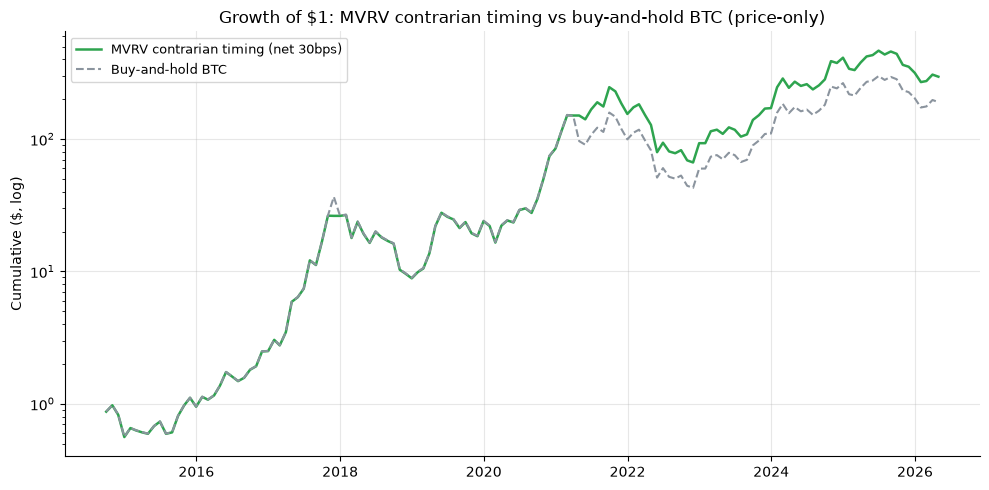

Timing rule: +71.4%/yr  SR=1.03  (long 97% of months)
Buy-and-hold: +69.2%/yr  SR=0.97
The 'edge' over holding is ~+2%/yr and not significant. It is buy-and-hold
that occasionally blinks to cash -- not a market timer.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
if HAVE_REAL:
    eq_net = (1 + bt["net"]).cumprod()
    eq_bh  = (1 + bt["bh"]).cumprod()
    ax.plot(eq_net.index, eq_net.values, color=GREEN, lw=1.8, label="MVRV contrarian timing (net 30bps)")
    ax.plot(eq_bh.index,  eq_bh.values,  color=GREY,  lw=1.5, ls="--", label="Buy-and-hold BTC")
    ax.set_yscale("log")
    s_net = st.summarize(bt["net"]); s_bh = st.summarize(bt["bh"])
    tim_ann, tim_sr = s_net["mean"]*1200, s_net["sharpe"]*12**0.5
    bh_ann, bh_sr = s_bh["mean"]*1200, s_bh["sharpe"]*12**0.5
    share = st.time_in_market(pos)
else:
    tim_ann, tim_sr = R["timing_ann"], R["timing_sr"]
    bh_ann, bh_sr = R["bh_ann"], R["bh_sr"]
    share = R["tim_share"]
    ax.text(0.5, 0.5, f"BTC cache absent\nFrozen: timing SR={tim_sr:.2f} ~ buy-hold SR={bh_sr:.2f}",
            ha="center", va="center", transform=ax.transAxes, fontsize=12, color=AMBER)
ax.set_title("Growth of $1: MVRV contrarian timing vs buy-and-hold BTC (price-only)")
ax.set_ylabel("Cumulative ($, log)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../docs/equity_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Timing rule: {tim_ann:+.1f}%/yr  SR={tim_sr:.2f}  (long {share:.0%} of months)")
print(f"Buy-and-hold: {bh_ann:+.1f}%/yr  SR={bh_sr:.2f}")
print("The 'edge' over holding is ~+2%/yr and not significant. It is buy-and-hold")
print("that occasionally blinks to cash -- not a market timer.")


## The bottom line for the curious

- The MVRV / price *co-movement* is real but it is a **mechanical link** (realized
  value is a slow average of past price), not a leading indicator.
- MVRV stretch does **not** predict next-month BTC returns (HAC *t* < 2, R^2 ~ 0).
- The "sell the over-heated top" band looks sharp but fires on **four months** in
  twelve years -- the 2017 and 2021 tops.
- The contrarian timing rule is **97% buy-and-hold** and its edge over simply
  holding is statistically zero.

This is a textbook **None / Mirage**: a beloved on-chain gauge whose apparent
edge is hindsight band-fitting on a single survivor.


*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*